# Outline
- Use Univariate and Multivariate Techniques to identify Outliers

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
houses = pd.read_csv('../2. EDA/houses.csv',index_col=0)

In [3]:
houses.drop(columns=['Sauna','Type','Building',
       'Jacuzzi', 'Security Staff', 'Maintenance Staff',
       'Facilities for Disabled', 'Laundry or Dry Cleaning Facility',
       'Communal/Shared Kitchen','Lobby in Building', 'Elevators',
       'Service Elevators in Building','Floor in Building'],inplace=True)

In [4]:
houses.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4521 entries, 0 to 6482
Data columns (total 25 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Main Location                       4521 non-null   object 
 1   Price(Cr)                           4521 non-null   float64
 2   Bath(s)                             4432 non-null   float64
 3   Area(Marla)                         4521 non-null   float64
 4   Bedroom(s)                          4442 non-null   float64
 5   Description                         4521 non-null   object 
 6   Amenities: Main Features            4210 non-null   object 
 7   Amenities: Rooms                    4117 non-null   object 
 8   Amenities: Healthcare Recreational  3630 non-null   object 
 9   Amenities: Other Facilities         3963 non-null   object 
 10  IsPrimeLoc                          4521 non-null   bool   
 11  SolarInstalled                      4521 non-nul

In [5]:
print('Houses Duplicated',houses.duplicated().sum())

Houses Duplicated 0


## Univariate Outlier Detection
- Z Score --> for Normal Distributions
- IQR --> for Non Normal Distributions

### Price

<Axes: ylabel='Price(Cr)'>

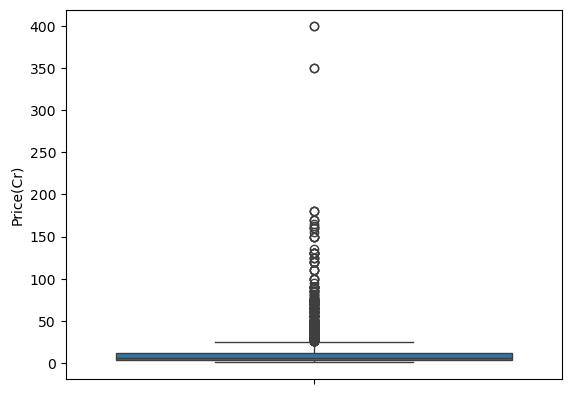

In [11]:
sns.boxplot(houses['Price(Cr)'])

In [12]:
# Analyzing the rows where Price > 150 Cr
print('Shape of Houses having Price greater than 100 Cr : ',houses[houses['Price(Cr)']>100].shape[0])
houses[houses['Price(Cr)']>100][['Main Location', 'Price(Cr)', 'Area(Marla)']].sort_values(by='Price(Cr)', ascending=False)

Shape of Houses having Price greater than 100 Cr :  40


,Main Location,Price(Cr),Area(Marla)
520,F-7,400.0,80.0
2679,F-7,400.0,80.0
2321,Main Margalla Road,350.0,80.0
5534,Main Margalla Road,350.0,80.0
1450,F-7,180.0,80.0
3929,F-7,180.0,80.0
2680,F-7,180.0,80.0
1156,F-7,170.0,80.0
3933,E-7,170.0,50.0
3728,E-7,170.0,50.0


In [13]:
# All rows included
houses.groupby('Main Location')['Price(Cr)'].mean().sort_values(ascending=False).head(10)

Main Location
Main Margalla Road    350.000000
E-7                    88.277778
F-7                    62.602083
F-6                    50.814815
G-6                    43.177778
F-8                    41.122889
Chak Shahzad           40.000000
Gulberg Greens         29.912500
F-10                   25.176364
G-7                    23.500000
Name: Price(Cr), dtype: float64

In [14]:
# All rows except the rows where Price less than 150 Cr
houses[houses['Price(Cr)']<150].groupby('Main Location')['Price(Cr)'].mean().sort_values(ascending=False).head(10)

Main Location
E-7               78.468750
F-7               51.745575
F-6               43.643564
G-6               43.177778
F-8               41.122889
Chak Shahzad      40.000000
Gulberg Greens    29.912500
F-10              25.176364
G-7               23.500000
F-11              18.649765
Name: Price(Cr), dtype: float64

*Although F-6, F-8, F-10, G-6, E-7 etc are high cost sectors, but removing outliers still has the same distribution. So we will drop them*

In [15]:
houses = houses[~(houses['Price(Cr)']>=150)]

In [16]:
houses.shape

(4501, 25)

<Axes: ylabel='Price(Cr)'>

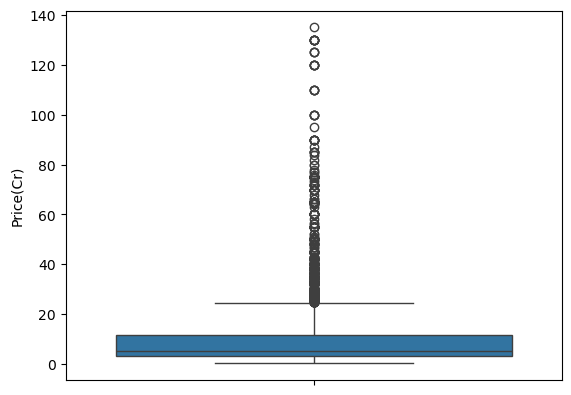

In [17]:
sns.boxplot(houses['Price(Cr)'])

<Axes: ylabel='Price(Cr)'>

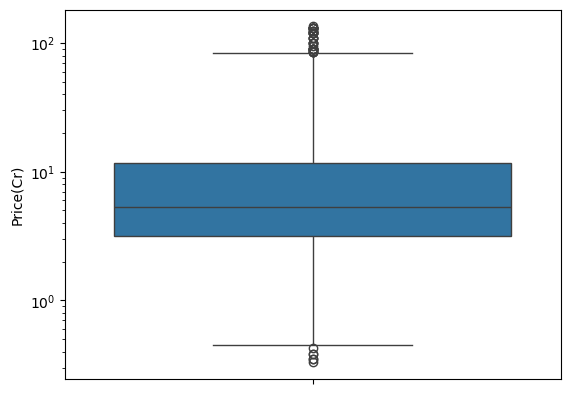

In [18]:
# Now the Price column is normal (it could be beneficial for Predciting)
sns.boxplot(houses['Price(Cr)'],log_scale=True)

### Area(Marla)

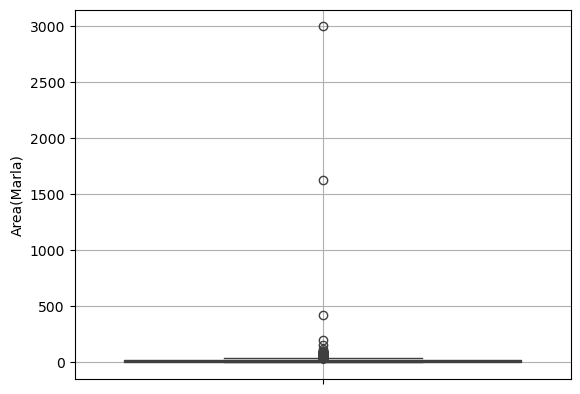

In [22]:
sns.boxplot(houses['Area(Marla)'])
plt.grid()

In [24]:
# Removed the 3 Obvious Outlier
houses = houses[houses['Area(Marla)'] != houses['Area(Marla)'].max()]
houses = houses[houses['Area(Marla)'] != houses['Area(Marla)'].max()]
houses = houses[houses['Area(Marla)'] != houses['Area(Marla)'].max()]

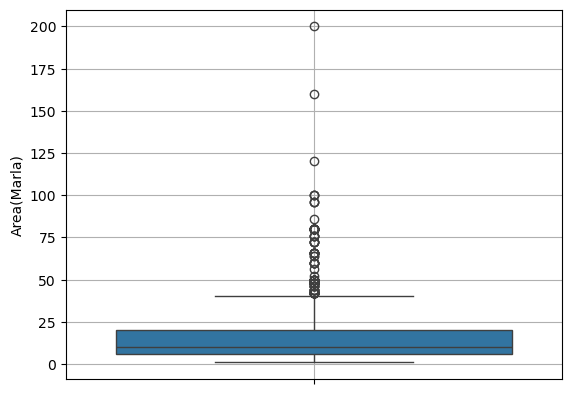

In [25]:
sns.boxplot(houses['Area(Marla)'])
plt.grid()

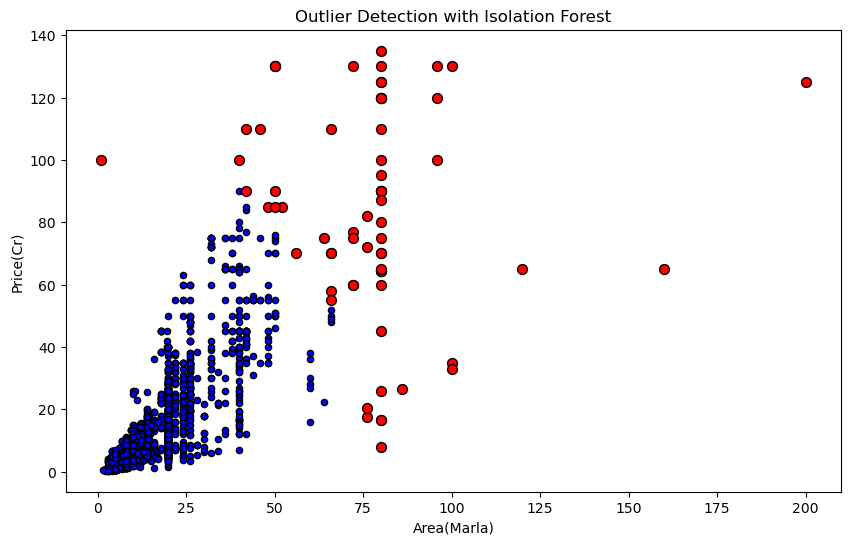

In [55]:
from sklearn.ensemble import IsolationForest

X = houses[['Price(Cr)','Area(Marla)']]
clf = IsolationForest(n_estimators=200,contamination=0.015)

y_pred = clf.fit_predict(X)

is_outlier_forest = y_pred == -1

plt.figure(figsize=(10, 6))
plt.scatter(X.loc[:,'Area(Marla)'],X.loc[:,'Price(Cr)'], color='b', s=20, edgecolor='k')


plt.scatter(X.loc[is_outlier_forest,'Area(Marla)'], X.loc[is_outlier_forest, 'Price(Cr)'], color='r', s=50, edgecolor='k')

plt.title("Outlier Detection with Isolation Forest")
plt.xlabel("Area(Marla)")
plt.ylabel("Price(Cr)")
plt.show()


<Axes: xlabel='Area(Marla)', ylabel='Price(Cr)'>

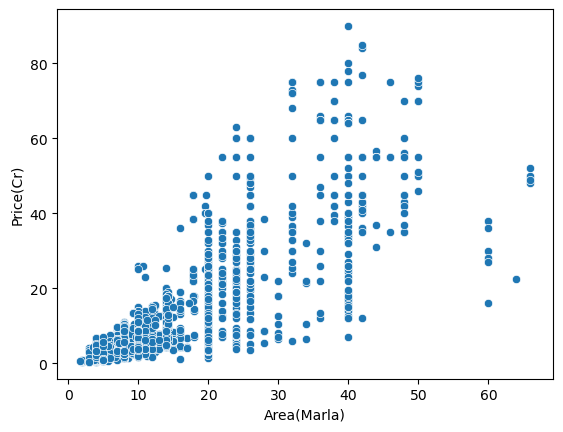

In [56]:
# Scatter plot with out Outliers
sns.scatterplot(data=houses.loc[~is_outlier_forest], x='Area(Marla)',y='Price(Cr)')

In [57]:
# Analyzing the rows having more Area but very less Price
houses[(houses['Area(Marla)']>60) & (houses['Price(Cr)']<40)]

,Main Location,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,Amenities: Healthcare Recreational,Amenities: Other Facilities,...,Built in year,Parking Spaces,Floor,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Swimming Pool,Storey Unit
448,Gulberg Greens,35.0,7.0,100.0,8.0,Live Like the King You Are Meant to Be. Your P...,"Built in year: 2025, Parking Spaces: 8, Double...",NaN,NaN,NaN,...,2025.0,8.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
534,Bani Gala,16.5,6.0,80.0,10.0,4 Kanal Luxury House 1 Sweet Bed With TV Loung...,"Parking Spaces: 1, Double Glazed Windows, Cent...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 1...","Lawn or Garden, Sauna, Jacuzzi","Maintenance Staff, Security Staff",...,NaN,1.0,NaN,3.0,4.0,1.0,2.0,NaN,NaN,NaN
763,Bahria Town,22.5,6.0,64.0,6.0,Bahira Town Garden City 3.25 Kanal House For S...,"Built in year: 2024, Parking Spaces: 5, Double...","Bedrooms: 6, Bathrooms: 7, Servant Quarters: 2...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Maintenance Staff, Security Staff, Facilities ...",...,2024.0,5.0,2.0,6.0,7.0,2.0,1.0,1.0,1.0,1.0
1273,Bahria Garden City,17.5,6.0,76.0,6.0,So if you're interested in buying this propert...,"Built in year, Parking Spaces: 3, Double Glaze...","Bedrooms: 8, Bathrooms: 8, Servant Quarters: 1...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Maintenance Staff, Security Staff, Facilities ...",...,1.0,3.0,NaN,8.0,8.0,1.0,2.0,1.0,1.0,NaN
1275,Bahria Town,20.5,6.0,76.0,5.0,About this rental 80% work complete Featuring ...,"Built in year: 2025, Parking Spaces: 5, Double...","Bedrooms: 5, Bathrooms: 6, Servant Quarters: 2...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Maintenance Staff, Security Staff, Facilities ...",...,2025.0,5.0,2.0,5.0,6.0,2.0,1.0,1.0,1.0,NaN
1714,Kashmir Highway,26.0,6.0,80.0,6.0,LUXURY VILLAS FOR SALE EIGHTEEN KASHMIR HIGHWA...,"Built in year: 2021, Parking Spaces: 3, Double...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 1...","Lawn or Garden, Sauna, Jacuzzi, Other Healthca...","Maintenance Staff, Security Staff, Facilities ...",...,2021.0,3.0,1.0,6.0,6.0,1.0,2.0,2.0,NaN,NaN
3191,Bahria Garden City,16.5,7.0,80.0,9.0,Exceptional 4 Kanal 8 Marla Structure for Sale...,"Built in year: 2018, Parking Spaces, Double Gl...","Bedrooms: 8, Bathrooms: 9, Servant Quarters: 2...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Maintenance Staff, Security Staff, Facilities ...",...,2018.0,1.0,4.0,8.0,9.0,2.0,3.0,2.0,1.0,NaN
3678,Simly Dam Road,8.0,6.0,80.0,6.0,Houses and apartments for sale in Simly Dam Ro...,"Built in year: 2025, Parking Spaces: 6, Double...","Bedrooms: 3, Bathrooms: 4, Servant Quarters: 2...","Lawn or Garden, Sauna, Jacuzzi","Security Staff, Other Facilities",...,2025.0,6.0,NaN,3.0,4.0,2.0,2.0,1.0,NaN,NaN
4219,Gulberg Greens,33.0,6.0,100.0,6.0,Gulberg Greens A Beautiful And Fully Renovated...,"Parking Spaces: 1, Double Glazed Windows, Floo...",NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6236,Gulberg Greens,26.5,6.0,86.0,9.0,Indulge in unparalleled luxury with this stunn...,"Built in year: 2023, Parking Spaces: 8, Double...","Bedrooms: 5, Bathrooms: 7, Servant Quarters: 1...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Maintenance Staff, Security Staff, Facilities ...",...,2023.0,8.0,2.0,5.0,7.0,1.0,1.0,1.0,1.0,NaN


<Axes: ylabel='Area(Marla)'>

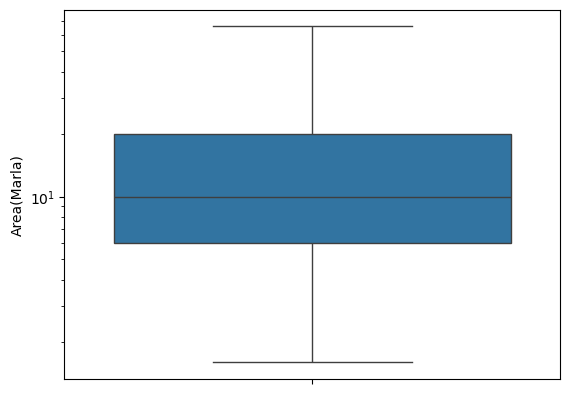

In [58]:
sns.boxplot(data=houses.loc[~is_outlier_forest],y='Area(Marla)',log_scale=True)

*Removing the Outliers*

In [59]:
# Removing the rows where Area(Marla) > 80
houses = houses.loc[~is_outlier_forest,:]

<Axes: ylabel='Area(Marla)'>

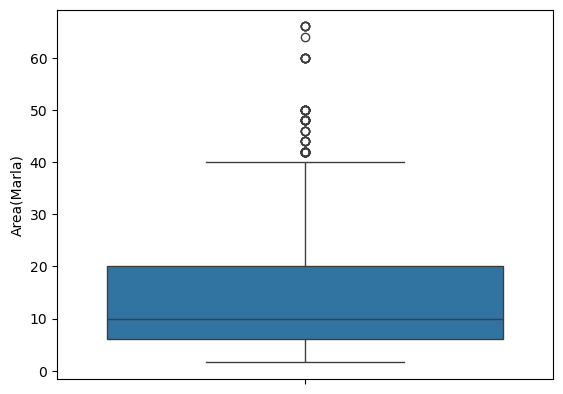

In [60]:
sns.boxplot(houses['Area(Marla)'])

### Bath(s) & Bedroom(s)

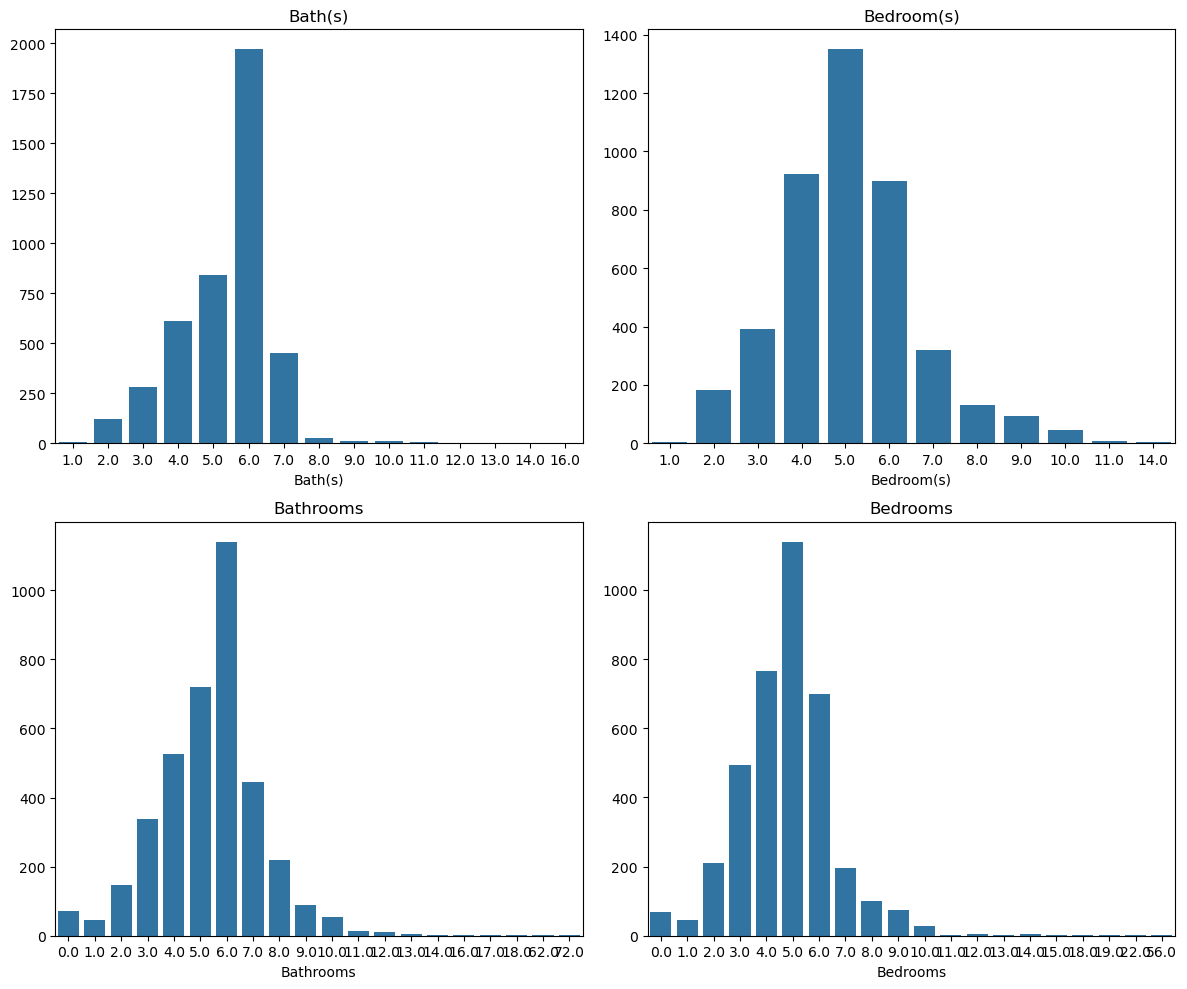

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialize the figure and a 2x2 grid of axes
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 2. Plot each column on its respective axis
# Row 0, Col 0: Bath(s)
sns.barplot(x=houses['Bath(s)'].value_counts().index, 
            y=houses['Bath(s)'].value_counts().values, 
            ax=axes[0, 0]).set_title('Bath(s)')

# Row 0, Col 1: Bedroom(s)
sns.barplot(x=houses['Bedroom(s)'].value_counts().index, 
            y=houses['Bedroom(s)'].value_counts().values, 
            ax=axes[0, 1]).set_title('Bedroom(s)')

# Row 1, Col 0: Bathrooms
sns.barplot(x=houses['Bathrooms'].value_counts().index, 
            y=houses['Bathrooms'].value_counts().values, 
            ax=axes[1, 0]).set_title('Bathrooms')

# Row 1, Col 1: Bedrooms
sns.barplot(x=houses['Bedrooms'].value_counts().index, 
            y=houses['Bedrooms'].value_counts().values, 
            ax=axes[1, 1]).set_title('Bedrooms')

# 3. Clean up the layout so titles don't overlap
plt.tight_layout()
plt.show()

In [63]:
# Analyzing the Houses having more than 8 Bath(s)
houses[houses['Bath(s)']>=8][['Main Location','Price(Cr)','Area(Marla)','Bedroom(s)','Bath(s)','Storey Unit','Floor']]

,Main Location,Price(Cr),Area(Marla),Bedroom(s),Bath(s),Storey Unit,Floor
219,F-10,30.00,28.0,8.0,8.0,NaN,1.0
226,Soan Garden,6.65,20.0,7.0,9.0,2.0,2.0
438,F-7,42.50,42.0,4.0,10.0,NaN,2.0
558,F-11,18.50,20.0,8.0,8.0,NaN,3.0
587,DHA Phase 2,12.00,20.0,6.0,8.0,NaN,2.0
801,F-7,32.00,26.0,10.0,10.0,3.0,3.0
812,F-7,38.00,40.0,8.0,9.0,NaN,2.0
833,Top City 1,7.50,20.0,8.0,9.0,2.0,1.0
983,DHA Phase 2,7.75,20.0,6.0,8.0,NaN,2.0
1053,Gulberg Residencia,11.00,20.0,9.0,9.0,1.0,3.0


<Axes: xlabel='Bath(s)', ylabel='Bedroom(s)'>

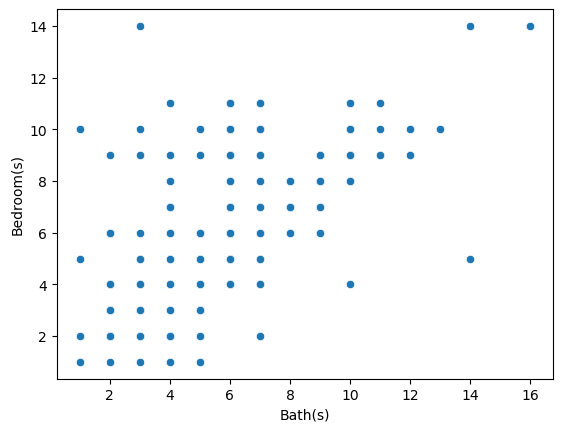

In [64]:
sns.scatterplot(x=houses['Bath(s)'],y=houses['Bedroom(s)'])

*Using Multivaraite Approaches to Detect Outliers*

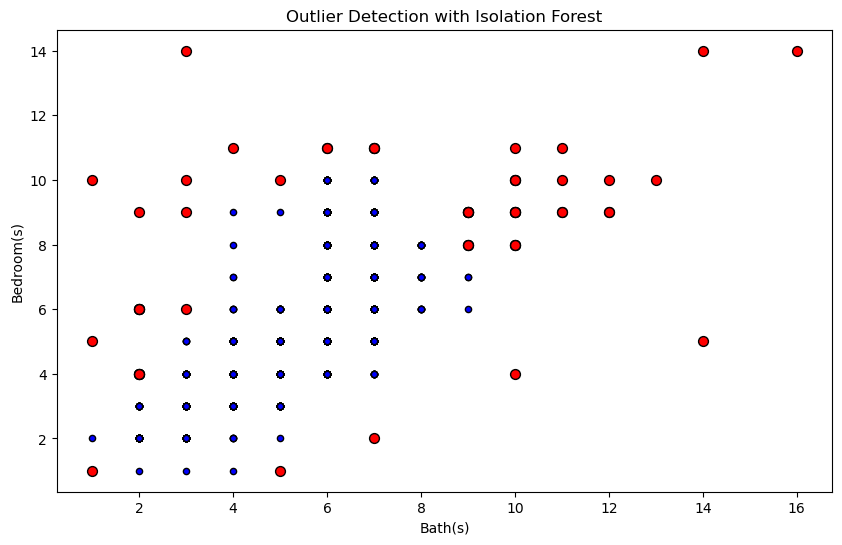

In [70]:
# Using Isolation to determine outliers between Bathrooms and Bedrooms
from sklearn.ensemble import IsolationForest

X = houses[['Bath(s)','Bedroom(s)']]
clf = IsolationForest(n_estimators=200,contamination=0.015)

y_pred = clf.fit_predict(X)

is_outlier_forest = y_pred == -1

plt.figure(figsize=(10, 6))
plt.scatter(X.loc[:,'Bath(s)'],X.loc[:,'Bedroom(s)'], color='b', s=20, edgecolor='k')


plt.scatter(X.loc[is_outlier_forest,'Bath(s)'], X.loc[is_outlier_forest, 'Bedroom(s)'], color='r', s=50, edgecolor='k')

plt.title("Outlier Detection with Isolation Forest")
plt.xlabel("Bath(s)")
plt.ylabel("Bedroom(s)")
plt.show()


In [124]:
X.isnull().sum()

Bath(s)       37
Bedroom(s)    30
dtype: int64

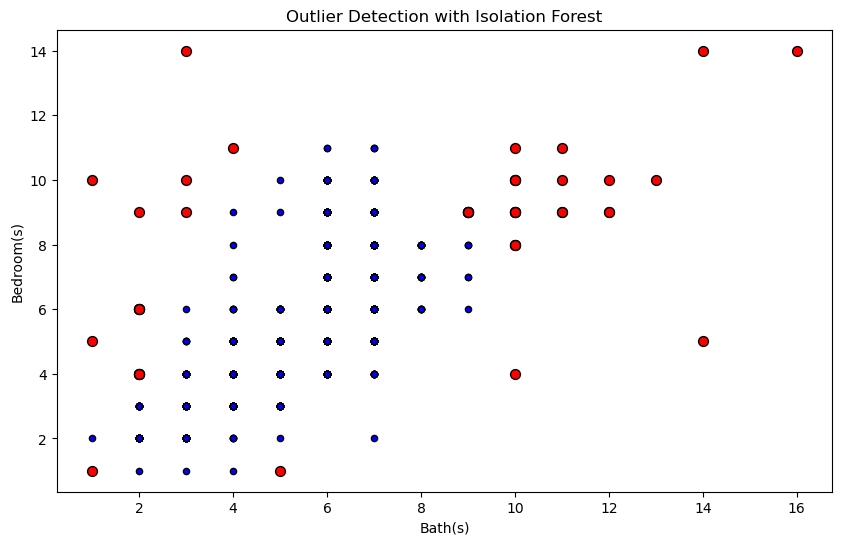

In [69]:
# Using Isolation to determine outliers between Bathrooms and Bedrooms
from sklearn.ensemble import IsolationForest

X = houses[['Bath(s)','Bedroom(s)']]
clf = IsolationForest(n_estimators=200,contamination=0.01)

y_pred = clf.fit_predict(X)

is_outlier_forest = y_pred == -1

plt.figure(figsize=(10, 6))
plt.scatter(X.loc[:,'Bath(s)'],X.loc[:,'Bedroom(s)'], color='b', s=20, edgecolor='k')


plt.scatter(X.loc[is_outlier_forest,'Bath(s)'], X.loc[is_outlier_forest, 'Bedroom(s)'], color='r', s=50, edgecolor='k')

plt.title("Outlier Detection with Isolation Forest")
plt.xlabel("Bath(s)")
plt.ylabel("Bedroom(s)")
plt.show()


C:\Users\Wajih\anaconda3\Lib\site-packages\sklearn\neighbors\_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


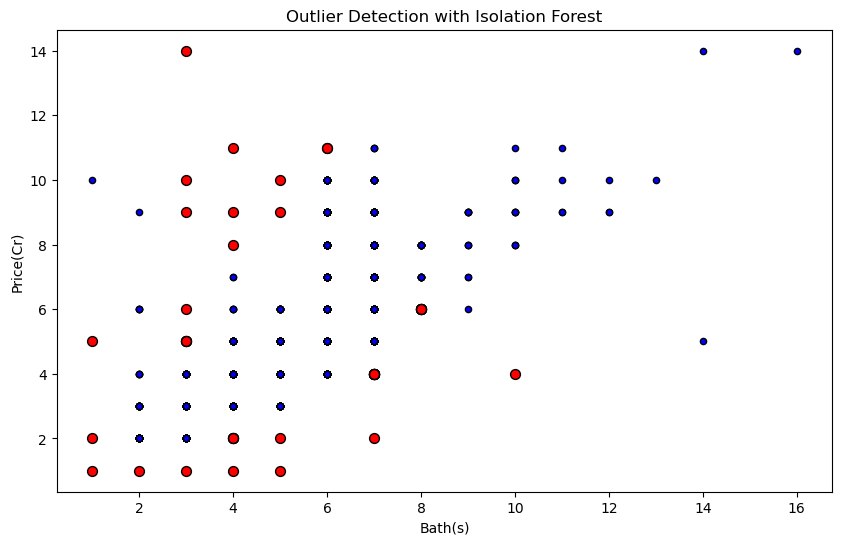

In [71]:
# Using LOF to determine outliers between Bathrooms and Bedrooms

X = houses.dropna(subset=['Bath(s)','Bedroom(s)'],how='any')

from sklearn.neighbors import LocalOutlierFactor

clf = LocalOutlierFactor(contamination = 0.01)
y_pred = clf.fit_predict(X[['Bath(s)','Bedroom(s)']])

is_outlier = y_pred == -1

plt.figure(figsize=(10, 6))
plt.scatter(X.loc[:,'Bath(s)'],X.loc[:,'Bedroom(s)'], color='b', s=20, edgecolor='k')


plt.scatter(X.loc[is_outlier,'Bath(s)'], X.loc[is_outlier, 'Bedroom(s)'], color='r', s=50, edgecolor='k')

plt.title("Outlier Detection with Isolation Forest")
plt.xlabel("Bath(s)")
plt.ylabel("Price(Cr)")
plt.show()

**The Mulitvariate Outlier Detection is not working as it should be, so the best way is to remove those rows where the difference between Bathrooms and Bedrooms is greater than 3**

In [72]:
houses['BedBath_Diff'] = houses['Bedroom(s)'] - houses['Bath(s)']

In [73]:
outlier_rows = houses[(houses['BedBath_Diff']>3)|(houses['BedBath_Diff']<-3)]

In [74]:
outlier_rows[['Area(Marla)','Storey Unit','Floor','Bath(s)','Bedroom(s)']]

,Area(Marla),Storey Unit,Floor,Bath(s),Bedroom(s)
39,36.0,NaN,NaN,6.0,10.0
368,20.0,NaN,2.0,6.0,10.0
438,42.0,NaN,2.0,10.0,4.0
1295,5.0,1.0,3.0,5.0,1.0
1367,20.0,3.0,3.0,6.0,10.0
1397,26.0,3.0,1.0,6.0,10.0
1429,40.0,NaN,1.0,2.0,6.0
1685,20.0,NaN,3.0,6.0,10.0
1862,14.0,3.0,2.0,6.0,10.0
2202,20.0,NaN,2.0,4.0,8.0


<Axes: xlabel='Bath(s)', ylabel='Bedroom(s)'>

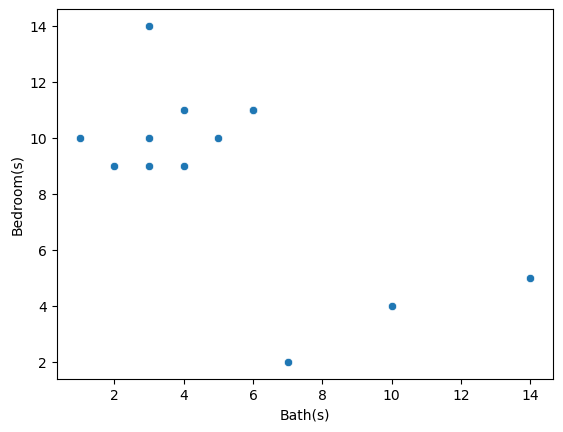

In [75]:
sns.scatterplot(data=houses[(houses['BedBath_Diff']>4)|(houses['BedBath_Diff']<-4)],x='Bath(s)',y='Bedroom(s)')

In [76]:
outlier_rows.shape

(47, 26)

In [77]:
outlier_rows[['Price(Cr)', 'Bath(s)','Area(Marla)', 'Bedroom(s)']]

,Price(Cr),Bath(s),Area(Marla),Bedroom(s)
39,55.00,6.0,36.0,10.0
368,24.00,6.0,20.0,10.0
438,42.50,10.0,42.0,4.0
1295,2.35,5.0,5.0,1.0
1367,10.90,6.0,20.0,10.0
1397,25.00,6.0,26.0,10.0
1429,75.00,2.0,40.0,6.0
1685,12.00,6.0,20.0,10.0
1862,18.00,6.0,14.0,10.0
2202,18.00,4.0,20.0,8.0


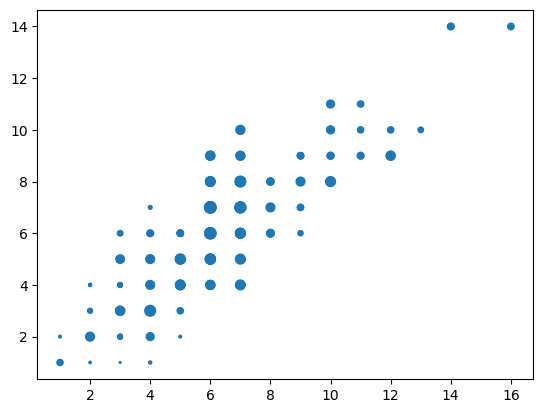

In [79]:
scatter = plt.scatter(data=houses.drop(index=outlier_rows.index),x='Bath(s)',y='Bedroom(s)',s='Area(Marla)')

In [80]:
outlier_rows.index

Index([  39,  368,  438, 1295, 1367, 1397, 1429, 1685, 1862, 2202, 2335, 2358,
       2372, 2732, 2858, 2941, 2983, 3082, 3208, 3279, 3293, 3459, 3483, 3515,
       3555, 3580, 3646, 3854, 4037, 4062, 4179, 4503, 4589, 4672, 4868, 4960,
       4992, 5092, 5141, 5212, 5502, 5522, 5566, 5569, 6232, 6234, 6454],
      dtype='int64')

In [81]:
# Removing the outliers rows
houses.drop(outlier_rows.index,inplace=True)

In [82]:
houses.shape

(4383, 26)

### Built in Year

In [94]:
houses['Built in year'].value_counts().sort_index().head(60)

Built in year
0.0          1
1.0        187
2.0         18
3.0          4
4.0          5
5.0          3
6.0          4
7.0          2
8.0          1
10.0         7
15.0         1
18.0         1
20.0         2
25.0         1
1887.0       1
1889.0       1
1898.0       1
1970.0       1
1978.0       1
1980.0       1
1981.0       1
1982.0       1
1984.0       1
1985.0       3
1987.0       1
1988.0       2
1990.0      17
1992.0       2
1995.0       5
1997.0       3
1998.0      12
1999.0      12
2000.0      53
2001.0       6
2002.0      10
2003.0       1
2004.0       1
2005.0      22
2006.0       1
2007.0       2
2008.0       8
2009.0       8
2010.0      52
2011.0       4
2012.0      22
2013.0       9
2014.0      21
2015.0      82
2016.0      38
2017.0      31
2018.0      61
2019.0      34
2020.0     112
2021.0      70
2022.0     114
2023.0     203
2024.0     529
2025.0    1743
2026.0      37
2027.0       3
Name: count, dtype: int64

In [87]:
houses[houses['Built in year']==2050]

,Main Location,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,Amenities: Healthcare Recreational,Amenities: Other Facilities,...,Parking Spaces,Floor,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Swimming Pool,Storey Unit,BedBath_Diff
230,Gulberg Residencia,4.2,7.0,7.0,5.0,Block F Near to park 5 bad 7 bath 2 lounge 2 k...,"Built in year: 2050, Parking Spaces: 3, Double...","Bedrooms: 6, Bathrooms: 7, Servant Quarters: 1...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Maintenance Staff, Security Staff, Facilities ...",...,3.0,3.0,6.0,7.0,1.0,2.0,1.0,1.0,NaN,-2.0


In [97]:
# There are many Errors, need to correct them manually

year_errors = {
    20242:2024,
    20223:2023,
    225:2025,
    2250:2025,
    2050:2025,
    20000:2000,
    205:2025,
    20242:2024,
    20001:2001,
    122024:2024
}

houses['Built in year'] = houses['Built in year'].replace(year_errors)

*Changing the Built in year of Brand New Houses to 2025*

In [163]:
newHouses = houses[(houses['Built in year']< 1800)&(houses['Description'].str.lower().str.contains('brand new'))].index

In [164]:
newHouses 

Index([   0,    6,    8,   34,   35,   49,   50,   67,  288,  440,  441,  451,
        699,  916, 1091, 1228, 1237, 1301, 1305, 1313, 1359, 1364, 1384, 1403,
       1405, 1571, 1678, 1719, 1735, 1782, 1906, 1907, 1974, 1995, 2154, 2215,
       2243, 2257, 2262, 2264, 2502, 2542, 2595, 2701],
      dtype='int64')

In [165]:
houses.loc[newHouses,'Built in year'] = 2025

In [93]:
# Set brand new Houses to 2025
newHouses = houses[(houses['Built in year'] < 1800) & (houses['Description'].str.lower().str.contains('brand new'))].index
houses.loc[newHouses, 'Built in year'] = 2025
print(f"Updated {len(newHouses)} brand new flats to year 2025")

Updated 0 brand new flats to year 2025


*Changing the value to Nan where Built in year is misleading (e.g where there is values less than 1800)*

In [95]:
Nanyear = houses[houses['Built in year']<1900].index

houses.loc[Nanyear,'Built in year'] = np.nan

In [99]:
houses['Built in year'].value_counts().sort_index()

Built in year
1970.0       1
1978.0       1
1980.0       1
1981.0       1
1982.0       1
1984.0       1
1985.0       3
1987.0       1
1988.0       2
1990.0      17
1992.0       2
1995.0       5
1997.0       3
1998.0      12
1999.0      12
2000.0      53
2001.0       7
2002.0      10
2003.0       1
2004.0       1
2005.0      22
2006.0       1
2007.0       2
2008.0       8
2009.0       8
2010.0      52
2011.0       4
2012.0      22
2013.0       9
2014.0      21
2015.0      82
2016.0      38
2017.0      31
2018.0      61
2019.0      34
2020.0     112
2021.0      70
2022.0     114
2023.0     203
2024.0     530
2025.0    1743
2026.0      37
2027.0       3
2028.0       1
2029.0       1
2055.0       2
Name: count, dtype: int64

### Parking Spaces

<Axes: xlabel='Parking Spaces', ylabel='count'>

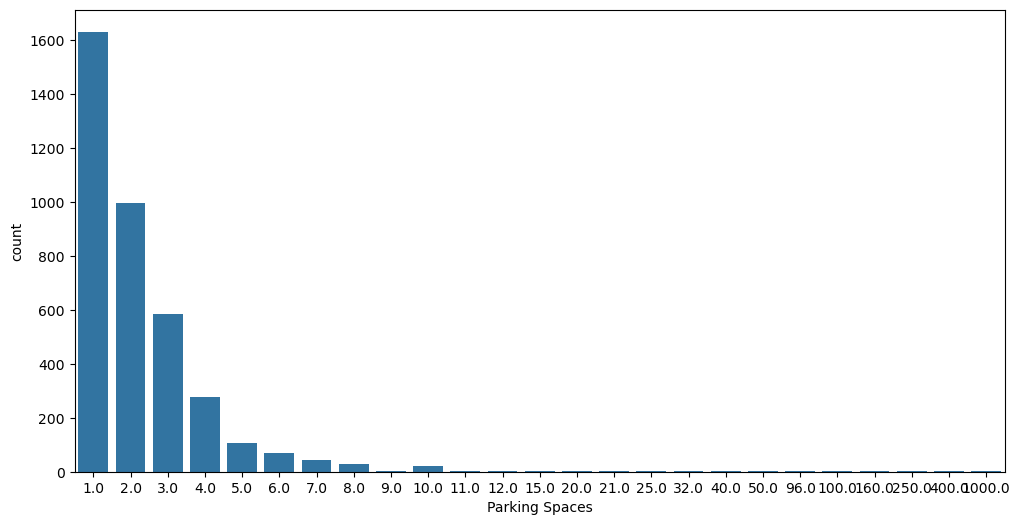

In [100]:
plt.figure(figsize=(12,6))
sns.barplot(houses['Parking Spaces'].value_counts())

In [103]:
houses['Parking Spaces'].value_counts()

Parking Spaces
1.0       1630
2.0        994
3.0        583
4.0        277
5.0        108
6.0         71
7.0         42
8.0         27
10.0        23
12.0         4
20.0         3
100.0        3
50.0         3
15.0         3
11.0         3
9.0          3
400.0        2
21.0         2
32.0         2
40.0         2
250.0        1
160.0        1
1000.0       1
96.0         1
25.0         1
Name: count, dtype: int64

In [104]:
houses[houses['Parking Spaces']>=5]

,Main Location,Price(Cr),Bath(s),Area(Marla),Bedroom(s),Description,Amenities: Main Features,Amenities: Rooms,Amenities: Healthcare Recreational,Amenities: Other Facilities,...,Parking Spaces,Floor,Bedrooms,Bathrooms,Servant Quarters,Kitchens,Store Rooms,Swimming Pool,Storey Unit,BedBath_Diff
26,Naval Anchorage,6.90,6.0,14.0,8.0,Naval Anchorage is full of real estate investm...,"Built in year: 2025, Parking Spaces: 6, Double...","Bedrooms: 8, Bathrooms: 8, Servant Quarters, D...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Maintenance Staff, Security Staff, Facilities ...",...,6.0,2.0,8.0,8.0,0.0,3.0,0.0,1.0,NaN,2.0
58,F-8,27.25,5.0,26.0,5.0,60*90 Corner House Available In F-8/4 On Good ...,"Parking Spaces: 5, Double Glazed Windows, Cent...","Bedrooms: 5, Bathrooms: 5, Servant Quarters: 1...",Other Healthcare and Recreation Facilities,"Maintenance Staff, Security Staff, Facilities ...",...,5.0,2.0,5.0,5.0,1.0,2.0,1.0,NaN,NaN,0.0
96,F-8,33.00,6.0,24.0,6.0,aoa dear sir. . . . we have good options in F8...,"Built in year: 2000, Parking Spaces: 5, Double...","Bedrooms: 5, Bathrooms: 7, Servant Quarters: 1...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Maintenance Staff, Security Staff, Facilities ...",...,5.0,2.0,5.0,7.0,1.0,2.0,1.0,1.0,NaN,0.0
98,F-10,35.00,7.0,40.0,8.0,Zawiya Enterprises Is An Established Real Esta...,"Built in year: 2000, Parking Spaces: 6, Double...","Bedrooms: 8, Bathrooms: 8, Servant Quarters: 1...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Maintenance Staff, Security Staff, Facilities ...",...,6.0,3.0,8.0,8.0,1.0,2.0,1.0,1.0,NaN,1.0
133,F-7,70.00,5.0,50.0,5.0,Demand : 72 cr size 1244 sq yard 80/140 f-7/3 ...,"Built in year: 2025, Parking Spaces: 06, Doubl...","Bedrooms: 07, Bathrooms: 08, Servant Quarters:...","Lawn or Garden, Sauna, Other Healthcare and Re...","Maintenance Staff, Security Staff, Facilities ...",...,6.0,3.0,7.0,8.0,3.0,2.0,3.0,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6238,Faisal Town Phase 1,3.00,6.0,8.0,6.0,We Believe in Fair Dealing through commitment ...,"Built in year, Parking Spaces: 8, Double Glaze...","Bedrooms: 4, Bathrooms: 5, Servant Quarters: 1...","Lawn or Garden, Other Healthcare and Recreatio...","Maintenance Staff, Security Staff, Facilities ...",...,8.0,2.0,4.0,5.0,1.0,1.0,1.0,NaN,NaN,0.0
6260,F-6,48.00,6.0,40.0,6.0,Your Property Requirement Just One Call Away! ...,"Built in year: 2021, Parking Spaces: 400, Doub...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 1...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Maintenance Staff, Security Staff, Facilities ...",...,400.0,26.0,6.0,6.0,1.0,1.0,1.0,1.0,NaN,0.0
6299,Bani Gala,6.50,6.0,34.0,6.0,"35marla double story house having 6 bedrooms, ...","Built in year: 2024, Parking Spaces: 10, Doubl...","Bedrooms: 6, Bathrooms: 6, Servant Quarters: 1...","Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...","Maintenance Staff, Security Staff, Facilities ...",...,10.0,2.0,6.0,6.0,1.0,2.0,1.0,1.0,2.0,0.0
6397,F-17,3.00,6.0,8.0,4.0,8 Marla Double Unit House Available. For Sale ...,"Built in year: 2013, Parking Spaces: 8, Double...","Bedrooms: 7, Bathrooms: 7, Servant Quarters: 2...","Lawn or Garden, Swimming Pool, Other Healthcar...","Maintenance Staff, Security Staff, Facilities ...",...,8.0,3.0,7.0,7.0,2.0,2.0,2.0,1.0,2.0,-2.0


<Axes: xlabel='Area(Marla)', ylabel='Parking Spaces'>

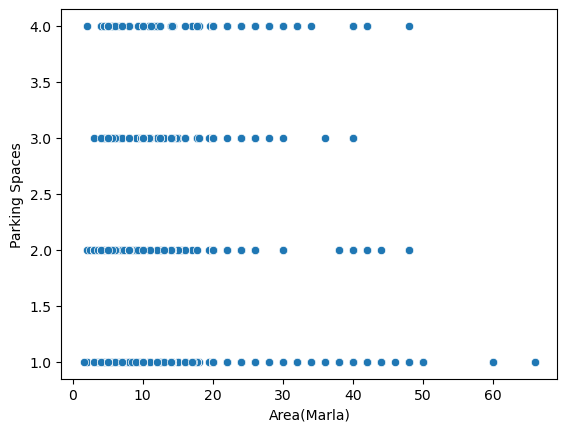

In [105]:
sns.scatterplot(houses[houses['Parking Spaces']<=4],x='Area(Marla)',y='Parking Spaces')

*By looking at this chart, we can deduce that the Parking Space column is misleading even though it looks useful.*

The reason could be human error, the agent exaggerated this feature.

**So the best thing is to drop it to avoid any error in the model**

### Floor and Storey Unit

*Storey Unit is more reliable because we directly extracted from the description column.*

### What to do:

1. Use Storey Unit as the Floor column
2. And use Floor column where Storey Unit information is missing.

<Axes: xlabel='Floor', ylabel='count'>

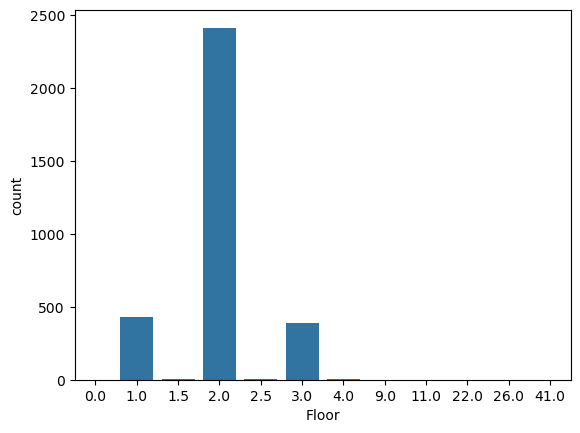

In [106]:
sns.barplot(houses['Floor'].value_counts())

<Axes: xlabel='Storey Unit', ylabel='count'>

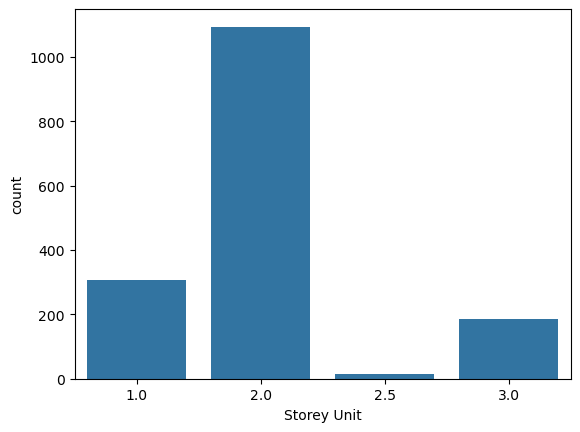

In [108]:
sns.barplot(houses['Storey Unit'].value_counts())

In [109]:
Nanstorey = houses['Storey Unit'].isnull()[houses['Storey Unit'].isnull()==True].index

In [110]:
houses.loc[Nanstorey,'Storey Unit'] = houses.loc[Nanstorey,'Floor']

<Axes: xlabel='Storey Unit', ylabel='count'>

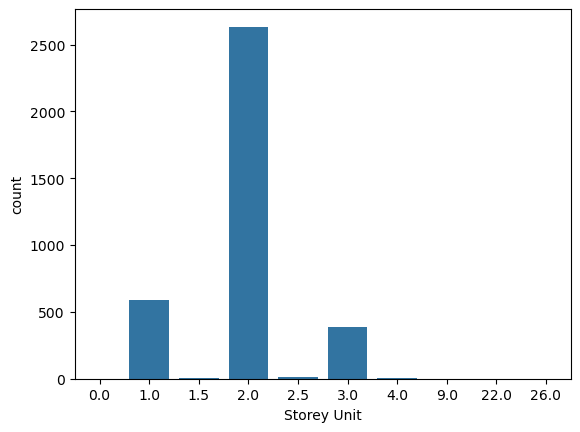

In [111]:
sns.barplot(houses['Storey Unit'].value_counts())

In [113]:
# Setting the cap to 1 and 3
houses['Storey Unit'] = houses['Storey Unit'].clip(lower=1,upper=3)

### Servant Quarter

In [114]:
houses['Servant Quarters'].value_counts()

Servant Quarters
1.0     2238
2.0      693
0.0      420
3.0       48
4.0        7
6.0        3
8.0        3
12.0       2
11.0       1
7.0        1
5.0        1
Name: count, dtype: int64

<Axes: xlabel='Servant Quarters', ylabel='count'>

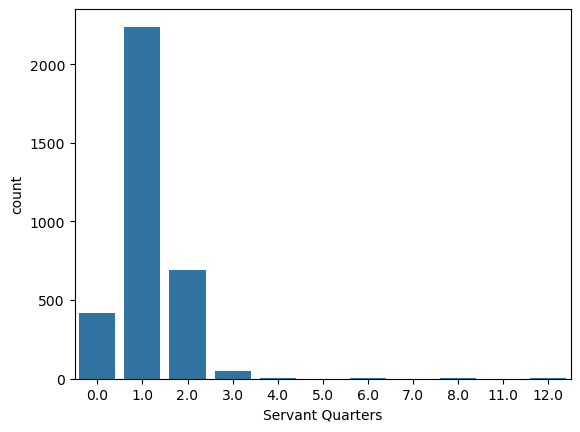

In [115]:
sns.barplot(houses['Servant Quarters'].value_counts())

*Setting to Nan for equal to 0 and 2+*

In [116]:
Nanservantquar = houses[~houses['Servant Quarters'].isin([1,2])].index

In [117]:
houses.loc[Nanservantquar,'Servant Quarters'] = np.nan

### Store Rooms

<Axes: xlabel='Store Rooms', ylabel='count'>

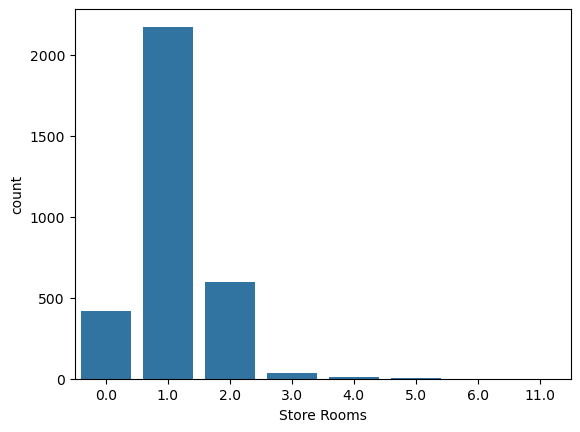

In [118]:
sns.barplot(houses['Store Rooms'].value_counts())

*Setting to Nan for equal to 0 and 2+*

In [119]:
Nanstore = houses[~houses['Store Rooms'].isin([1,2,3])].index

In [120]:
houses.loc[Nanstore,'Store Rooms'] = np.nan

### Kitchens 

<Axes: xlabel='Kitchens', ylabel='count'>

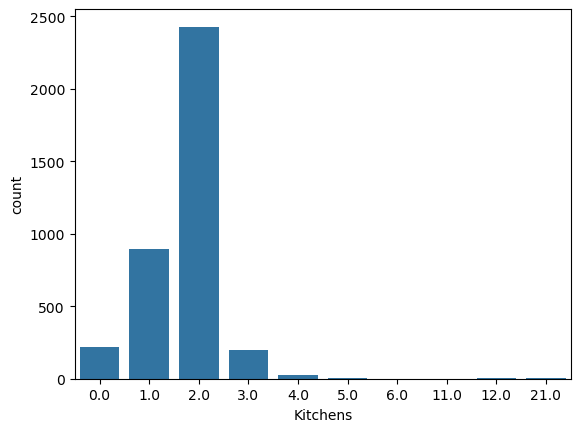

In [121]:
sns.barplot(houses['Kitchens'].value_counts())

In [137]:
houses[houses['Kitchens']>3].index

Index([], dtype='int64')

In [135]:
houses.loc[2261]

Main Location                                                               DHA Phase 2
Price(Cr)                                                                          13.9
Bath(s)                                                                             7.0
Area(Marla)                                                                        20.0
Bedroom(s)                                                                          6.0
Description                           Kanal House For Sale in DHA phase 2 Islamabad ...
Amenities: Main Features              Built in year: 2025, Parking Spaces: 3, Double...
Amenities: Rooms                      Bedrooms: 6, Bathrooms: 7, Servant Quarters: 2...
Amenities: Healthcare Recreational    Lawn or Garden, Swimming Pool, Sauna, Jacuzzi,...
Amenities: Other Facilities           Maintenance Staff, Security Staff, Facilities ...
IsPrimeLoc                                                                        False
SolarInstalled                  

In [127]:
houses['Description'].loc[237]

'G-13 Brand New 500 Yds Architect Design Owner Build Double Story House Prime Location Complete Imported Fitting And Fixtures Elite CLASS Construction House 6 Master Bedrooms Attached Stylish Bathrooms Two Drawing Dining Two TV Lounge Two American Style Huge Kitchen With Dirty Kitchen , Store Two Servant Quarter HUGE LUSH GREEN LAWN Huge Car Parking Spaces Reasonable Price Contact Only Serious Buyers Negotiable Price Contact Al Hafiz Estate F-11 ISLAMABAD'

*Upon further analyzing, Kitchens > 3 seems outlier, so we will change them to Nan values*

In [128]:
Nankitchens = houses[~houses['Kitchens'].isin([1,2,3])].index

In [129]:
houses.loc[Nankitchens,'Kitchens'] = np.nan

In [130]:
houses['Kitchens'].value_counts()

Kitchens
2.0    2428
1.0     895
3.0     201
Name: count, dtype: int64

In [282]:
# Saving the file

In [139]:
houses.to_csv('houses_outlier_handled.csv')